# Question 1: TF-IDF Vectorization
# Task: Convert the text data into a TF-IDF matrix and display the features.

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "I love machine learning and NLP.",
    "TF-IDF is a popular method in text mining.",
    "Natural Language Processing is fascinating.",
    "I love learning new things in NLP."
]

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

features = vectorizer.get_feature_names_out()

print("Features (Vocabulary):")
print(features)

print("\nTF-IDF Matrix:")
print(tfidf_matrix.toarray())

Features (Vocabulary):
['and' 'fascinating' 'idf' 'in' 'is' 'language' 'learning' 'love'
 'machine' 'method' 'mining' 'natural' 'new' 'nlp' 'popular' 'processing'
 'text' 'tf' 'things']

TF-IDF Matrix:
[[0.50867187 0.         0.         0.         0.         0.
  0.40104275 0.40104275 0.50867187 0.         0.         0.
  0.         0.40104275 0.         0.         0.         0.
  0.        ]
 [0.         0.         0.37156534 0.29294639 0.29294639 0.
  0.         0.         0.         0.37156534 0.37156534 0.
  0.         0.         0.37156534 0.         0.37156534 0.37156534
  0.        ]
 [0.         0.46516193 0.         0.         0.36673901 0.46516193
  0.         0.         0.         0.         0.         0.46516193
  0.         0.         0.         0.46516193 0.         0.
  0.        ]
 [0.         0.         0.         0.37222485 0.         0.
  0.37222485 0.37222485 0.         0.         0.         0.
  0.47212003 0.37222485 0.         0.         0.         0.
  0.47212003

# Question 2: CountVectorizer
# Task: Use CountVectorizer to find word frequency.

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

texts = [
    "ChatGPT is an LLM model.",
    "ChatGPT is useful for NLP tasks.",
    "NLP involves working with language."
]

vectorizer = CountVectorizer()

count_matrix = vectorizer.fit_transform(texts)

features = vectorizer.get_feature_names_out()

df_counts = pd.DataFrame(count_matrix.toarray(), columns=features)

print("Features (Vocabulary):")
print(features)

print("\nWord Frequency Matrix:")
print(df_counts)

Features (Vocabulary):
['an' 'chatgpt' 'for' 'involves' 'is' 'language' 'llm' 'model' 'nlp'
 'tasks' 'useful' 'with' 'working']

Word Frequency Matrix:
   an  chatgpt  for  involves  is  language  llm  model  nlp  tasks  useful  \
0   1        1    0         0   1         0    1      1    0      0       0   
1   0        1    1         0   1         0    0      0    1      1       1   
2   0        0    0         1   0         1    0      0    1      0       0   

   with  working  
0     0        0  
1     0        0  
2     1        1  


# Question 3: Topic Modeling using LDA
# Task: Apply Latent Dirichlet Allocation (LDA) to find topics from the text.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

documents = [
    "Data science is an interdisciplinary field.",
    "Artificial intelligence and machine learning are part of data science.",
    "Natural language processing helps computers understand text.",
    "Deep learning is useful in image and text processing."
]

vectorizer = CountVectorizer(stop_words='english')
count_matrix = vectorizer.fit_transform(documents)

lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(count_matrix)

features = vectorizer.get_feature_names_out()

def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx+1}:")
        top_features = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print("  " + ", ".join(top_features))

display_topics(lda, features, no_top_words=5)

Topic 1:
  science, data, learning, artificial, intelligence
Topic 2:
  text, processing, language, understand, helps


# Question 4: Sentiment Analysis using VADER
# Task: Analyze sentiment of given text reviews.

In [4]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

analyzer = SentimentIntensityAnalyzer()

sentences = [
    "I love the new feature, it's amazing!",
    "This update is terrible and frustrating.",
    "The service was okay, not the best.",
    "I’m so happy with the experience!",
    "Very disappointed. Will not recommend."
]

for sentence in sentences:
    scores = analyzer.polarity_scores(sentence)
    print(f"Sentence: {sentence}")
    print(f"Scores: {scores}\n")

Sentence: I love the new feature, it's amazing!
Scores: {'neg': 0.0, 'neu': 0.325, 'pos': 0.675, 'compound': 0.8516}

Sentence: This update is terrible and frustrating.
Scores: {'neg': 0.6, 'neu': 0.4, 'pos': 0.0, 'compound': -0.7184}

Sentence: The service was okay, not the best.
Scores: {'neg': 0.328, 'neu': 0.487, 'pos': 0.185, 'compound': -0.3544}

Sentence: I’m so happy with the experience!
Scores: {'neg': 0.0, 'neu': 0.539, 'pos': 0.461, 'compound': 0.6468}

Sentence: Very disappointed. Will not recommend.
Scores: {'neg': 0.647, 'neu': 0.353, 'pos': 0.0, 'compound': -0.6708}



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\kalas\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Question 5: Generate a Word Cloud
# Task: Generate a word cloud from the input text.

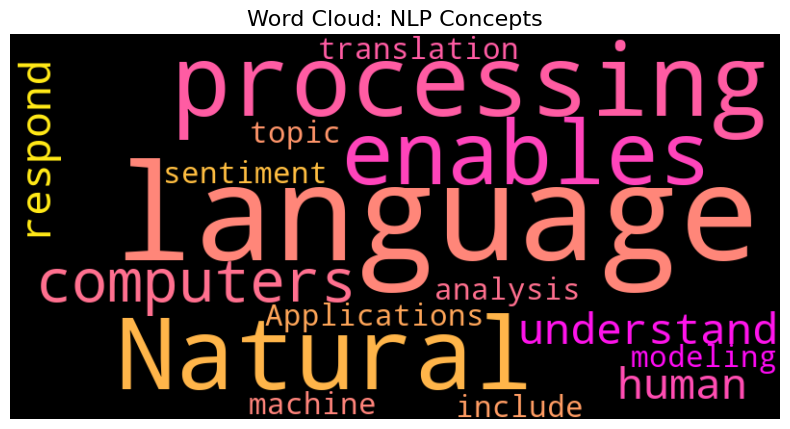

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = """
Natural language processing enables computers to understand and respond to human language.
Applications include sentiment analysis, machine translation, and topic modeling.
"""

wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='spring').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: NLP Concepts", fontsize=16)
plt.show()